In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import cv2
sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt

# Main purpose
This notebook examines a lot of different CV methods. The idea is to teach me the basics and generate ideas

# Image class
Much of the image processing in this notebook will be done using the Image class. This class will store the image data as a numpy array, along with the file name, location, and any relevant metadata. It will also provide methods for common image processing tasks such as morphological operations, thresholding, and display.

In [35]:
# We find the location of the processed TopBP1 z-projection data
path_to_folder = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data_processed\TopBP1_zproj"

# Specify the run number for the data to be loaded
run_number = "10_2"

# Loading the data in channel 1 and channel 2
Image_array_1 = CV_func.load_time_series(1, run_number, path_to_folder)
Image_array_2 = CV_func.load_time_series(2, run_number, path_to_folder)

# A sample image if we just need a single array
test_image = Image_array_1[0]

# Pre Processing

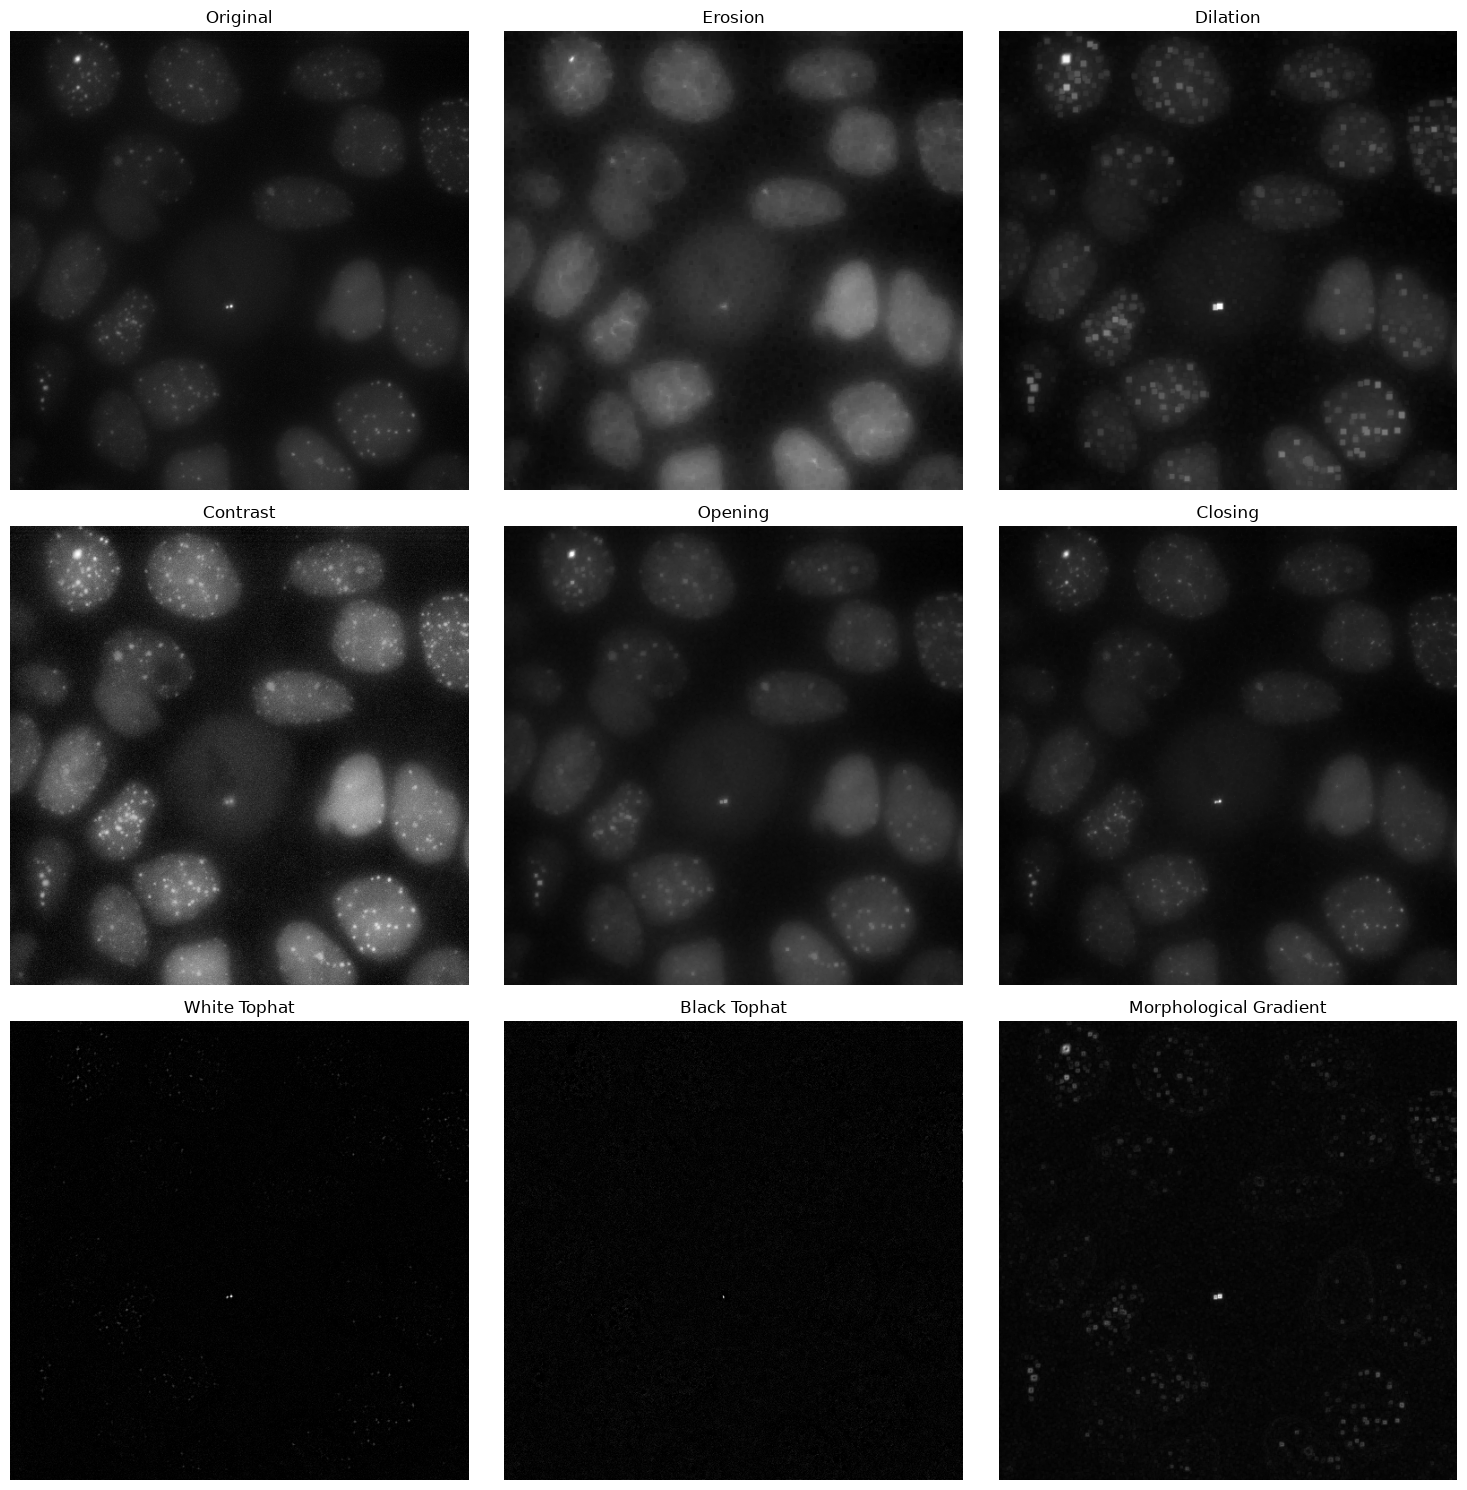

In [ ]:
# Load image and compare morphological operations, each applied independently to the original
image_number = 10
ksize = (3, 3)
iterations = 2

Image_1 = CV_func.load_image("timelapze_z", number=image_number, channel=2)

operations = [("Original", Image_1.array_original)]
morphological_ops = [
    ("Erosion", lambda: Image_1.erosion(ksize=ksize, iterations=iterations)),
    ("Dilation", lambda: Image_1.dilation(ksize=ksize, iterations=iterations)),
    ("Contrast", lambda: Image_1.contrast(clip_limit=1.0, tile_grid_size=(8, 8))),
    ("Opening", lambda: Image_1.opening(ksize=ksize)),
    ("Closing", lambda: Image_1.closing(ksize=ksize)),
    ("White Tophat", lambda: Image_1.white_tophat(ksize=ksize)),
    ("Black Tophat", lambda: Image_1.black_tophat(ksize=ksize)),
    ("Morphological Gradient", lambda: Image_1.morphological_gradient(ksize=ksize)),
]

for title, apply_op in morphological_ops:
    Image_1.reset()
    apply_op()
    operations.append((title, Image_1.array.copy()))

n_cols = 3
n_rows = int(np.ceil(len(operations) / n_cols))

plt.figure(figsize=(5 * n_cols, 5 * n_rows))
for idx, (title, img) in enumerate(operations):
    plt.subplot(n_rows, n_cols, idx + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
#plt.savefig("Morphological_Operations_Comparison.png")
plt.show()



# Methods for getting the target particles locations
## Comparing to average / Thresholding
This essentially just masks the highest intensity regions. As some places have high intensity without protein, it may not accurately reflect the presence of the target particles.

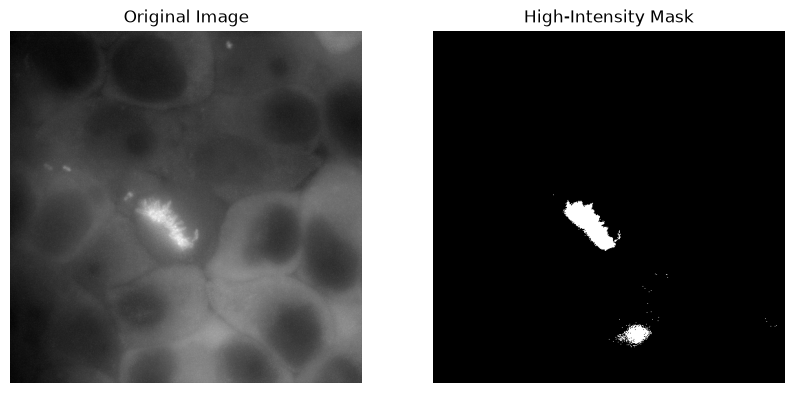

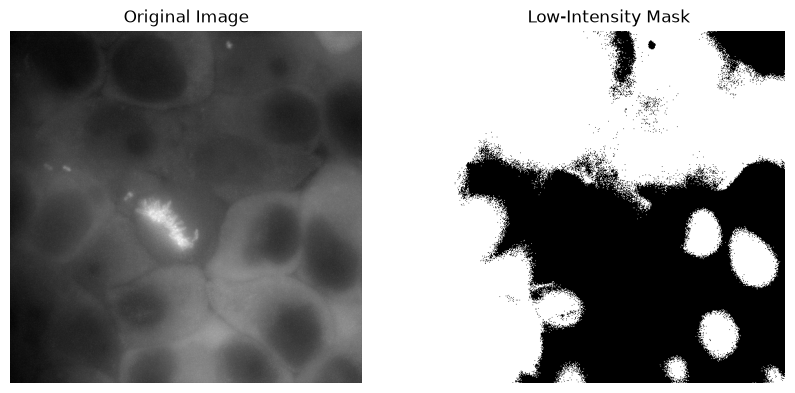

In [28]:
# Perform thresholding to identify high-intensity regions in the image
factor = 1.3
mask_array_1 = test_image.thresholding(thresh=int(test_image.average()*factor))
mask_array_2 = test_image.thresholding(thresh=int(test_image.average()*1), invert=True)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_image.array, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("High-Intensity Mask")
plt.axis("off")
plt.imshow(mask_array_1, cmap="gray")
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_image.array, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Low-Intensity Mask")
plt.axis("off")
plt.imshow(mask_array_2, cmap="gray")


## Adaptive Thresholding Disk method
Basic idea
- Start by creating random circles and figure out a way to find all points within
- Then we can calculate the average intensity within each circle
- Finally, we can set a threshold based on these average intensities to identify regions of interest

Further Extension:
- Perhaps introduce some kind of adaptive stepping, so we sample in interesting areas. Maybe even human assisted, where we click a point, and it marks all the interesting points around it. This could increase efficiency, although its very fast
- Perhaps extend to disks of different scew and orientations, instead of pure circles. 
- Perhaps run the algorithm for N=50 circles, N_repeat = 50 times, and have a vote between the results, random forest style. 

Running Notes:
- Normal thresholding finds a lot of uninteresting points. Adaptive thresholding works a lot better. 
- It runs almost instantly for 100 circles on the 512x512 image. But time depens heavily on circle size. STress testing might be needed

I have written that into functions in an external library

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

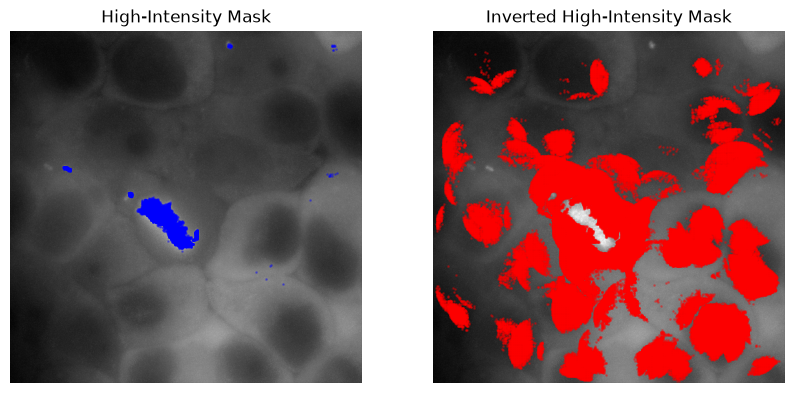

In [29]:
test_array = test_image.array

# Blur it using cv2
#test_array = cv2.GaussianBlur(test_array, (3, 3), 1.4)


plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("High-Intensity Mask")
target_points = CV_func.generate_target_points(test_array, num_circles=500, threshold_factor=1.2, r_min = 10, r_max = 50)
plt.scatter(target_points[:, 0], target_points[:, 1], s=1, c='blue', alpha=0.3)
plt.imshow(test_array, cmap='gray')
plt.axis("off")


test_array_inv = np.max(test_array) - test_array
target_points_inv = CV_func.generate_target_points(test_array_inv, num_circles=500, threshold_factor=1.1, r_min = 10, r_max = 50)
plt.subplot(1,2,2)
plt.title("Inverted High-Intensity Mask")
plt.scatter(target_points_inv[:, 0], target_points_inv[:, 1], s=1, c='red', alpha=0.3)
plt.imshow(test_array, cmap='gray')
plt.axis("off")

## Otsu's method
Without the ability to adjust the threshold manually, this is not very viable. Otsus method is essentially dealign with a global threshold. 

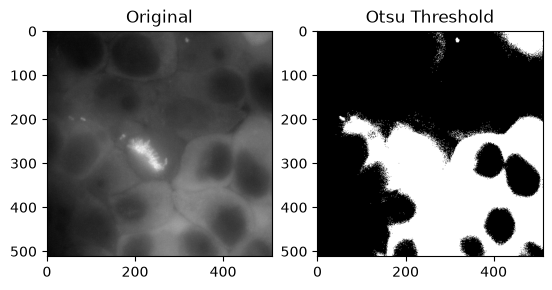

In [30]:
test_array = test_image.array


# adaptiveThreshold requires a single-channel 8-bit image
# Normalize the uint16 image to 0..255 first
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
#gray = cv2.GaussianBlur(gray, (5, 5), 1.4)

ret1, th1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display original and th1 side by side
plt.subplot(1, 2, 1)
plt.imshow(test_array, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(th1, cmap='gray')
plt.title('Otsu Threshold')
plt.show()

# Edge detection
## Sobel

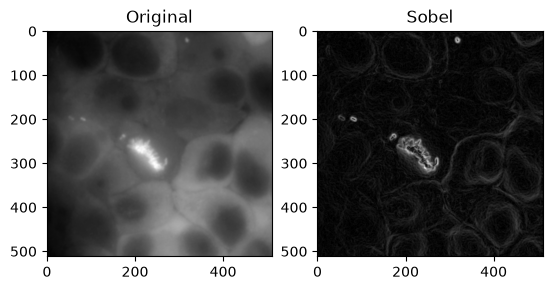

In [33]:
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gray = cv2.GaussianBlur(gray, (5, 5), 1.4)

ksize = 3
scale = 1
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize, scale=scale)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize, scale=scale)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)


# Display original and sobel side by side
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.show()



### Laplacian

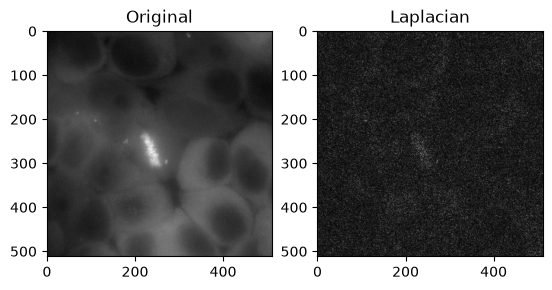

In [ ]:
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

laplacian = cv2.Laplacian(gray, cv2.CV_64F, ksize= 3 )
laplacian = cv2.convertScaleAbs(laplacian)

# Display original and laplacian side by side
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.show()

### Watershet

### Currently not working directly. Would require some parameter optimization

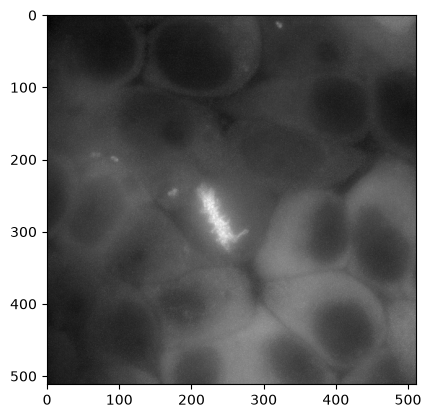

In [ ]:
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(gray, cmap='gray')


### SK-images canny
doesnt seem to work very well
https://stackoverflow.com/questions/55994311/image-segmentation-to-find-cells-in-biological-images

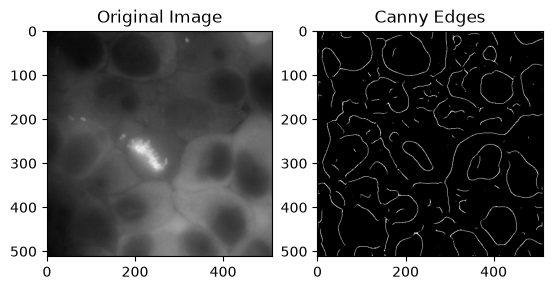

In [42]:
image = test_image.array


from skimage import feature
sigma_test = np.linspace(0.1, 10, 30)

canny = feature.canny(image, sigma=8, low_threshold=0.2, high_threshold=0.8)

# PLot orignal and edges side by side
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edges')
plt.show()




### Flow

THe idea is to start from a point, and then check similarity outwards from that point. 
The code currently only compares the intensity of neighboring pixels to determine similarity.
I should add:
- Knowledge about surroundings

Its currently able to do something about edges

 Points left to try: 364
Stopped, no more points to try


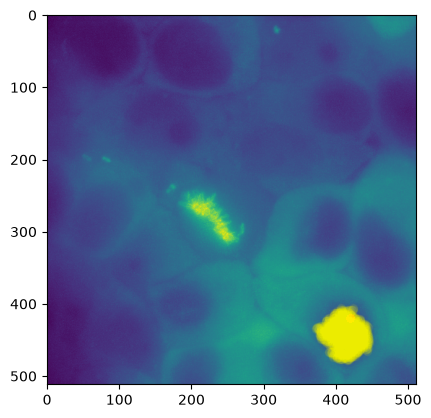

In [49]:
image = test_image.array
plt.imshow(image)
point = 420, 420
similarity_number = 10
meshgrid = np.meshgrid(np.arange(image.shape[1]), np.arange(image.shape[0]))

plt.scatter(*point, color='red')

points_in = [point]
points_out = []
points_to_try = [point]

flag = 0
while True:
    flag += 1
    if len(points_to_try) == 0:
        print("Stopped, no more points to try")
        break

    current_x = points_to_try[-1][0]
    current_y = points_to_try[-1][1]
    points_to_try.remove((current_x, current_y))
    current_intensity = image[current_y, current_x]
    neighbors = [(current_x + dx, current_y + dy) for dx in [-1, 0, 1] for dy in [-1, 0, 1] if (dx, dy) != (0, 0)]
    neighbors = [(x, y) for x, y in neighbors if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]]

    for neighbor_x, neighbor_y in neighbors:
        # Skip if neighbor has already been tried
        if (neighbor_x, neighbor_y) in points_in or (neighbor_x, neighbor_y) in points_out:
            continue
        neighbor_intensity = image[neighbor_y, neighbor_x]

        if abs(int(neighbor_intensity) - int(current_intensity)) < similarity_number:
            points_to_try.append((neighbor_x, neighbor_y))
            points_in.append((neighbor_x, neighbor_y))
            
        else:
            points_out.append((neighbor_x, neighbor_y))

    if flag % 1000 == 0:
        print(" Points left to try: " + str(len(points_to_try)))
    if flag > 6000:
        break

# Lets plot the points in
plt.imshow(image)
points_in_array = np.array(points_in)
plt.scatter(points_in_array[:, 0], points_in_array[:, 1], alpha = 0.05, color='yellow')
plt.show()


# Segmentation

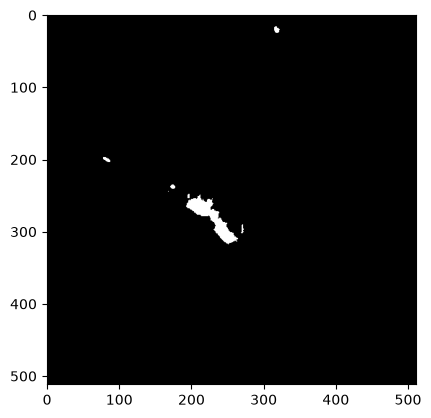

In [108]:
# Start på running some thresholding to get mask
test_image.reset(all = True)
test_image.blur(ksize=(3, 3))
th = test_image.adaptive_threshold(block_size=101, C = -int(test_image.average() * 0.03))
plt.imshow(th, cmap="gray")

## Region Growing Segmentation

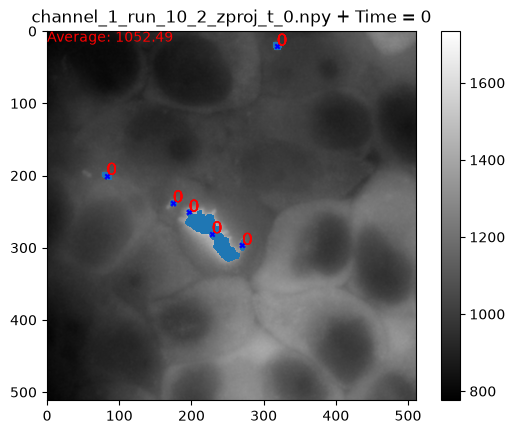

In [ ]:
marked_points = CV_func.get_marked_points(th)
segments = CV_func.region_growing(th, marked_points, min_size=10)
largest_segment = CV_func.get_largest_segment(segments)

for segment in segments:
    Segment = CV_class.Segment(segment, test_image)
    Segment.display()
    test_image.add_segment(Segment)

test_image.display(show_segments = True, show_data = True)